# 📄 Resume Analyzer — NLP Preprocessing Pipeline

## 🎯 Objective
The objective of this notebook is to preprocess raw resume data using Natural Language Processing (NLP) techniques. This step prepares the textual data so that it can be used effectively for machine learning models in the next phase.

---

## Pipeline Overview

This notebook performs the following steps:

1. Initialization and Library Import
2. Data Loading
3. Data Inspection
4. Text Cleaning
5. Tokenization
6. Lemmatization
7. Save Cleaned Data

---

## Dataset Description

The dataset contains the following columns:

- **ID** → Unique identifier for each resume (not used in ML)
- **Resume_str** → Raw resume text (primary input feature)
- **Resume_html** → HTML version of resume (optional, not used here)
- **Category** → Job category (target variable)

In [16]:
# ================================
# LIBRARY IMPORTS
# ================================

import pandas as pd
import numpy as np

# NLP Libraries
import re
import string

# NLTK for NLP processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Visualization (for later use)
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)

# ================================
#  DOWNLOADING NLTK RESOURCES
# ================================

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# ================================
# INITIALIZING NLP COMPONENTS
# ================================

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

print("NLP tools initialized successfully !")

[nltk_data] Downloading package punkt to C:\Users\Mandeep
[nltk_data]     Singh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Mandeep
[nltk_data]     Singh\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


NLP tools initialized successfully !


[nltk_data] Downloading package stopwords to C:\Users\Mandeep
[nltk_data]     Singh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Mandeep
[nltk_data]     Singh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Step 1: Data Loading and Initial Inspection

In this step, we are:
- Load the dataset from a CSV file into a pandas DataFrame
- Standardize column names
- Preview the dataset
- Examine its shape, columns, and data types

In [5]:
# Load dataset
df = pd.read_csv("Resume.csv")

# Clean column names (remove extra spaces if any)
df.columns = df.columns.str.strip()

# Preview first 5 rows
print("First 5 rows of dataset:")
display(df.head())


# ================================
# Basic Dataset Information
# ================================

print("\nDataset Shape (Rows, Columns):")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

First 5 rows of dataset:


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR Summary Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management. ...,"<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=""section firstsection"" id=""SECTION_NAME500375979"" style=""\n padding-top:0px;\n ""> <div class...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS Summary Versatile media professional with background in Communications, Marketing, Human Resources and Technology. Experience 09/201...","<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=""section firstsection"" id=""SECTION_NAME911808366"" style=""padding-top:0px;""> <div class=""paragraph PA...",HR
2,33176873,"HR DIRECTOR Summary Over 20 years experience in recruiting, 15 plus years in Human Resources Executive Management, 5 years of HRIS development and maintenance 4 years work...","<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=""section firstsection"" id=""SECTION_NAME1008511259"" style=""padding-top:0px;""> <div class=""paragraph P...",HR
3,27018550,"HR SPECIALIST Summary Dedicated, Driven, and Dynamic with over 20 years of customer service expertise. Motivated to maintain customer satisfaction and contribute to company succe...","<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=""section firstsection"" id=""SECTION_NAME992636658"" style=""padding-top:0px;""> <div class=""paragraph PA...",HR
4,17812897,HR MANAGER Skill Highlights HR SKILLS HR Department Startup Three New Organization Startups Employment Law FMLA/ADA/EEO/WC Mediation & Advocacy HR Policies & Proce...,"<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=""section firstsection"" id=""SECTION_NAME666809417"" style=""padding-top:0px;""> <div class=""paragraph PA...",HR



Dataset Shape (Rows, Columns):
(2484, 4)

Column Names:
['ID', 'Resume_str', 'Resume_html', 'Category']

Data Types:
ID             int64
Resume_str       str
Resume_html      str
Category         str
dtype: object


## Step 2: Missing Values and Data Quality Analysis

In this step, we are:
- Check for missing values in each column
- Calculate the percentage of missing data
- Identify duplicate records
- Ensure data integrity before preprocessing

In [6]:
print("Missing Values in Each Column:\n")

missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
})

display(missing_df)


# ================================
# Duplicate Records Check
# ================================

duplicate_count = df.duplicated().sum()

print("\nNumber of Duplicate Rows:", duplicate_count)

Missing Values in Each Column:



,Missing Values,Percentage (%)
ID,0,0.0
Resume_str,0,0.0
Resume_html,0,0.0
Category,0,0.0



Number of Duplicate Rows: 0


## Step 3: Category Distribution Analysis

In this step, we:
- Count the number of resumes in each category
- Analyze the distribution of classes
- Visualize the distribution using a bar plot

Category Distribution:



Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

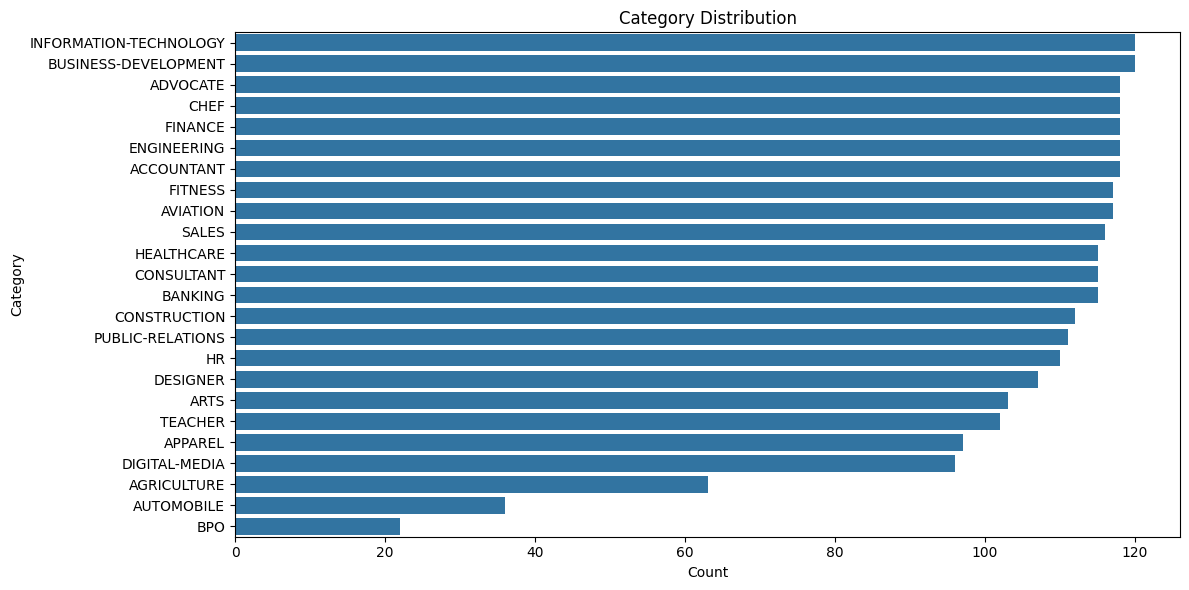

In [7]:
# Count values
category_counts = df['Category'].value_counts()

print("Category Distribution:\n")
display(category_counts)


# ================================
# Visualization
# ================================

plt.figure(figsize=(12, 6))
sns.countplot(y=df['Category'], order=category_counts.index)

plt.title("Category Distribution")
plt.xlabel("Count")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

## Step 4: Resume Length Analysis

In this step, we:
- Compute the length of each resume
- Generate descriptive statistics
- Visualize the distribution of resume lengths

This helps identify:
- Extremely short resumes (potential noise)
- Extremely long resumes (potential outliers)
- Overall text variability

Understanding text length is important before applying NLP techniques, as it can influence feature extraction and model performance.

Resume Length Statistics:



count     2484.000000
mean      6295.308776
std       2769.251458
min         21.000000
25%       5160.000000
50%       5886.500000
75%       7227.250000
max      38842.000000
Name: Resume_Length, dtype: float64

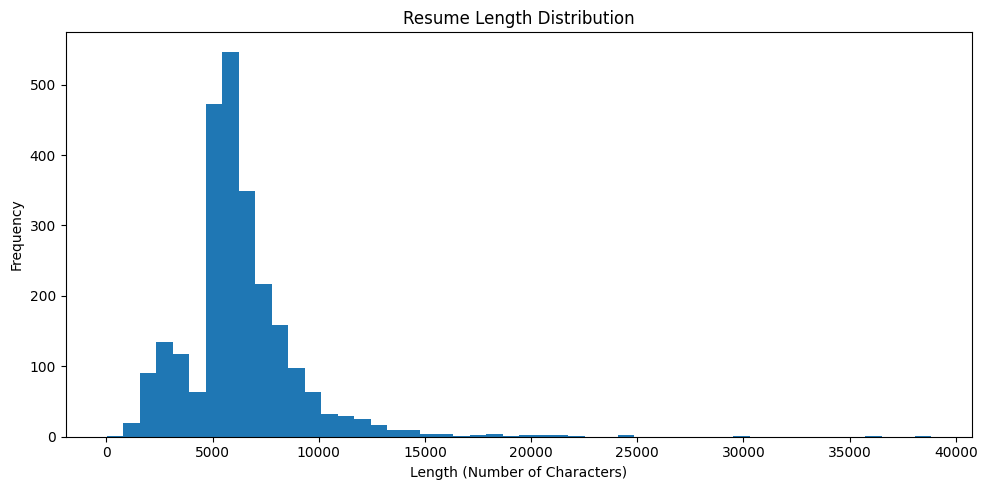

In [8]:
# Create a new column for resume length
df['Resume_Length'] = df['Resume_str'].astype(str).apply(len)

print("Resume Length Statistics:\n")
display(df['Resume_Length'].describe())


# ================================
# Visualization
# ================================

plt.figure(figsize=(10, 5))
plt.hist(df['Resume_Length'], bins=50)

plt.title("Resume Length Distribution")
plt.xlabel("Length (Number of Characters)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Step 5: Text Cleaning

In this step, we:
- Convert text to lowercase
- Remove URLs and special characters
- Remove punctuation
- Remove extra whitespace

This step ensures that the text is normalized and consistent, which is essential for accurate tokenization and feature extraction.

In [14]:
def clean_text(text):
    text = str(text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove HTML tags (safety)
    text = re.sub(r'<.*?>', '', text)
    
    # Remove punctuation
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


# ================================
# Apply Cleaning
# ================================

df['Cleaned_Resume'] = df['Resume_str'].apply(clean_text)

print("Sample Cleaned Text:\n")
print(df['Cleaned_Resume'].iloc[0][:1000])

Sample Cleaned Text:

hr administrator marketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service highlights focused on customer satisfaction team management marketing savvy conflict resolution techniques training and development skilled multi tasker client relations specialist accomplishments missouri dot supervisor training certification certified by ihg in customer loyalty and marketing by segment hilton worldwide general manager training certification accomplished trainer for cross server hospitality systems such as hilton onq micros opera pms fidelio opera reservation system ors holidex completed courses and seminars in customer service sales strategies inventory control loss prevention safety time management leadership and performance assessment experience hr admi

## Step 6: Tokenization and Stopword Removal

In this step, we:
- Split the cleaned text into individual words (tokens)
- Remove stopwords such as "the", "is", "and", etc.

This reduces noise and ensures that only meaningful words are retained for further processing.

In [17]:

def tokenize_and_remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return filtered_tokens


# Apply transformation
df['Tokens'] = df['Cleaned_Resume'].apply(tokenize_and_remove_stopwords)

print("Sample Tokens:\n")
print(df['Tokens'].iloc[0][:20])

Sample Tokens:

['hr', 'administrator', 'marketing', 'associate', 'hr', 'administrator', 'summary', 'dedicated', 'customer', 'service', 'manager', 'years', 'experience', 'hospitality', 'customer', 'service', 'management', 'respected', 'builder', 'leader']


## Step 7: Lemmatization

In this step, we:
- Apply lemmatization to each token
- Convert different forms of a word into a single base representation

This helps in reducing redundancy and improves the quality of features for machine learning models.

In [18]:
def lemmatize_tokens(tokens):
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens]
    return lemmatized


# Apply lemmatization
df['Lemmatized_Tokens'] = df['Tokens'].apply(lemmatize_tokens)

print("Sample Lemmatized Tokens:\n")
print(df['Lemmatized_Tokens'].iloc[0][:20])

Sample Lemmatized Tokens:

['hr', 'administrator', 'marketing', 'associate', 'hr', 'administrator', 'summary', 'dedicated', 'customer', 'service', 'manager', 'year', 'experience', 'hospitality', 'customer', 'service', 'management', 'respected', 'builder', 'leader']


## Step 8: Reconstruct Clean Text and Save Cleaned Dataset

In this step, we:
- Convert lemmatized tokens back into a single string
- Create a final cleaned text column
- Select only relevant columns for machine learning
- Save the processed dataset as a new CSV file

This ensures that the original dataset remains unchanged and a clean, reusable dataset is prepared for the next stage.

In [19]:
def reconstruct_text(tokens):
    return " ".join(tokens)

df['Final_Resume'] = df['Lemmatized_Tokens'].apply(reconstruct_text)

print("Sample Final Clean Text:\n")
print(df['Final_Resume'].iloc[0][:500])


# ================================
# Prepare Final Dataset
# ================================

final_df = df[['Final_Resume', 'Category']]

print("\nFinal Dataset Preview:\n")
display(final_df.head())


# ================================
# Save Cleaned Dataset
# ================================

final_df.to_csv("resume_cleaned.csv", index=False)

print("\nCleaned dataset saved as 'resume_cleaned.csv'")

Sample Final Clean Text:

hr administrator marketing associate hr administrator summary dedicated customer service manager year experience hospitality customer service management respected builder leader customer focused team strives instill shared enthusiastic commitment customer service highlight focused customer satisfaction team management marketing savvy conflict resolution technique training development skilled multi tasker client relation specialist accomplishment missouri dot supervisor training certification cer

Final Dataset Preview:



,Final_Resume,Category
0,hr administrator marketing associate hr administrator summary dedicated customer service manager year experience hospitality customer service management respected builder leader customer focused t...,HR
1,hr specialist u hr operation summary versatile medium professional background communication marketing human resource technology experience current hr specialist u hr operation company name city st...,HR
2,hr director summary year experience recruiting plus year human resource executive management year hris development maintenance year working healthcare enviroment skill recruiting fmla eeo flsa hri...,HR
3,hr specialist summary dedicated driven dynamic year customer service expertise motivated maintain customer satisfaction contribute company success emphasis personnel process management solid team ...,HR
4,hr manager skill highlight hr skill hr department startup three new organization startup employment law fmla ada eeo wc mediation advocacy hr policy procedure staff recruitment retention salary ne...,HR



Cleaned dataset saved as 'resume_cleaned.csv'
